# Factory Insight AI - Model Explainability

## 1. 目的

前フェーズではLightGBMと5-Fold Cross Validationを用いて
故障予測モデルを構築した。

OOF予測から判定閾値を決定し、
TestデータでPrecision 0.949、Recall 0.824、
F1 0.882、ROC-AUC 0.982、
Average Precision 0.892となった。

本NotebookではSHAPを用いて、
LightGBMがどの特徴量を根拠として
故障リスクを予測しているのかを分析する。

モデル全体の傾向だけではなく、
個別設備について故障リスクが高くなった理由も可視化し、
保全担当者がモデルの予測結果を理解できる状態を目指す。

## 2. データ読み込み

In [13]:
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

DATA_PATH = Path("../data/raw/ai4i2020.csv")

df = pd.read_csv(DATA_PATH)

df.shape

(10000, 14)

## 3. 派生特徴量

In [14]:
df_featured = df.copy()

df_featured["Power [W]"] = (
    2
    * np.pi
    * df_featured["Rotational speed [rpm]"]
    * df_featured["Torque [Nm]"]
    / 60
)

df_featured["Wear-Torque"] = (
    df_featured["Tool wear [min]"]
    * df_featured["Torque [Nm]"]
)

df_featured["Temperature difference [K]"] = (
    df_featured["Process temperature [K]"]
    - df_featured["Air temperature [K]"]
)

## 4. 特徴量と目的変数

In [15]:
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Power [W]",
    "Wear-Torque",
    "Temperature difference [K]",
]

categorical_features = [
    "Type",
]

target = "Machine failure"

X = df_featured[
    numeric_features + categorical_features
]

y = df_featured[target]

## 5. Train / Test分割

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_train.shape, X_test.shape

((8000, 9), (2000, 9))

## 6. 最終LightGBMの再現

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features,
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_features,
        ),
    ]
)

In [18]:
X_train_transformed = preprocessor.fit_transform(
    X_train
)

X_test_transformed = preprocessor.transform(
    X_test
)

feature_names = (
    preprocessor.get_feature_names_out()
)

feature_names = [
    name
    .replace("num__", "")
    .replace("cat__", "")
    .replace("[", "(")
    .replace("]", ")")
    for name in feature_names
]

feature_names

['Air temperature (K)',
 'Process temperature (K)',
 'Rotational speed (rpm)',
 'Torque (Nm)',
 'Tool wear (min)',
 'Power (W)',
 'Wear-Torque',
 'Temperature difference (K)',
 'Type_H',
 'Type_L',
 'Type_M']

In [19]:
X_train_explain = pd.DataFrame(
    X_train_transformed,
    columns=feature_names,
    index=X_train.index,
)

X_test_explain = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index,
)

X_train_explain.head()

,Air temperature (K),Process temperature (K),Rotational speed (rpm),Torque (Nm),Tool wear (min),Power (W),Wear-Torque,Temperature difference (K),Type_H,Type_L,Type_M
4058,302.0,310.9,1456.0,47.2,54.0,7196.676675,2548.8,8.9,0.0,0.0,1.0
1221,297.0,308.3,1399.0,46.4,132.0,6797.736296,6124.8,11.3,0.0,0.0,1.0
6895,301.0,311.6,1357.0,45.6,137.0,6479.974671,6247.2,10.6,0.0,0.0,1.0
9863,298.9,309.8,1411.0,56.3,84.0,8318.864043,4729.2,10.9,0.0,1.0,0.0
8711,297.1,308.5,1733.0,28.7,50.0,5208.456932,1435.0,11.4,0.0,1.0,0.0


In [20]:
from lightgbm import LGBMClassifier

final_lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)

final_lgbm_model.fit(
    X_train_explain,
    y_train,
)

,learning_rate,0.05
,n_estimators,300
,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [21]:
selected_threshold = 0.4802020202020202

test_proba = final_lgbm_model.predict_proba(
    X_test_explain
)[:, 1]

test_pred = (
    test_proba >= selected_threshold
).astype(int)

In [22]:
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

print(
    "Precision:",
    precision_score(y_test, test_pred),
)

print(
    "Recall:",
    recall_score(y_test, test_pred),
)

print(
    "F1:",
    f1_score(y_test, test_pred),
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, test_proba),
)

print(
    "Average Precision:",
    average_precision_score(
        y_test,
        test_proba,
    ),
)

confusion_matrix(
    y_test,
    test_pred,
)

Precision: 0.9491525423728814
Recall: 0.8235294117647058
F1: 0.8818897637795275
ROC-AUC: 0.9819525636341493
Average Precision: 0.8918387642868745


array([[1929,    3],
       [  12,   56]])

## 7. SHAP値の計算

In [23]:
explainer = shap.TreeExplainer(
    final_lgbm_model
)

shap_values = explainer(
    X_test_explain
)

shap_values

.values =
array([[-1.80725755e-01,  6.86302139e-01, -5.99553229e-01, ...,
        -1.36734668e-03, -3.35099263e-02,  1.83662021e-01],
       [ 4.18732690e-01, -4.46692666e-01, -2.93529673e-01, ...,
         1.60702024e-02, -1.31065291e-02, -9.39241915e-02],
       [-1.00212448e-01, -4.49952985e-02, -6.85649907e-01, ...,
         7.11780969e-04,  3.92857772e-02,  1.43811259e-01],
       ...,
       [-3.91993091e-02, -6.73734451e-01,  3.34444857e-01, ...,
        -6.29368384e-03,  2.05216974e-03, -1.77360840e-01],
       [-3.38777774e-01,  3.47710055e-01,  8.86060484e-01, ...,
         1.49798803e-02,  5.67310047e-02, -1.87769673e-01],
       [ 1.28686214e-02, -6.46526852e-01, -4.43858870e-01, ...,
        -2.76299051e-03, -5.45833908e-02, -1.94990596e-02]],
      shape=(2000, 11))

.base_values =
array([-11.38351238, -11.38351238, -11.38351238, ..., -11.38351238,
       -11.38351238, -11.38351238], shape=(2000,))

.data =
array([[3.005e+02, 3.098e+02, 1.345e+03, ..., 0.000e+00, 1.000e+0

In [24]:
shap_values.values.shape

(2000, 11)

## 8. SHAP特徴量重要度

In [25]:
mean_abs_shap = np.abs(
    shap_values.values
).mean(axis=0)

shap_importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap,
    }
).sort_values(
    "mean_abs_shap",
    ascending=False,
)

shap_importance_df

,feature,mean_abs_shap
4,Tool wear (min),0.837623
2,Rotational speed (rpm),0.736660
7,Temperature difference (K),0.731359
5,Power (W),0.481910
1,Process temperature (K),0.415412
3,Torque (Nm),0.411985
6,Wear-Torque,0.396324
0,Air temperature (K),0.252710
10,Type_M,0.118092
9,Type_L,0.067733


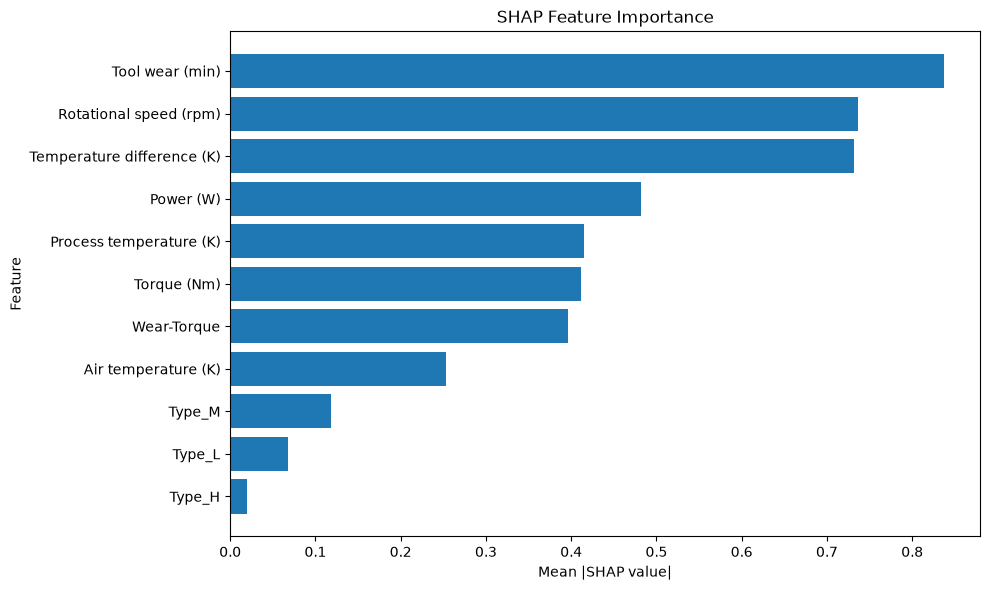

In [26]:
plt.figure(figsize=(10, 6))

plt.barh(
    shap_importance_df["feature"][::-1],
    shap_importance_df["mean_abs_shap"][::-1],
)

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

## 9. SHAP Summary Plot

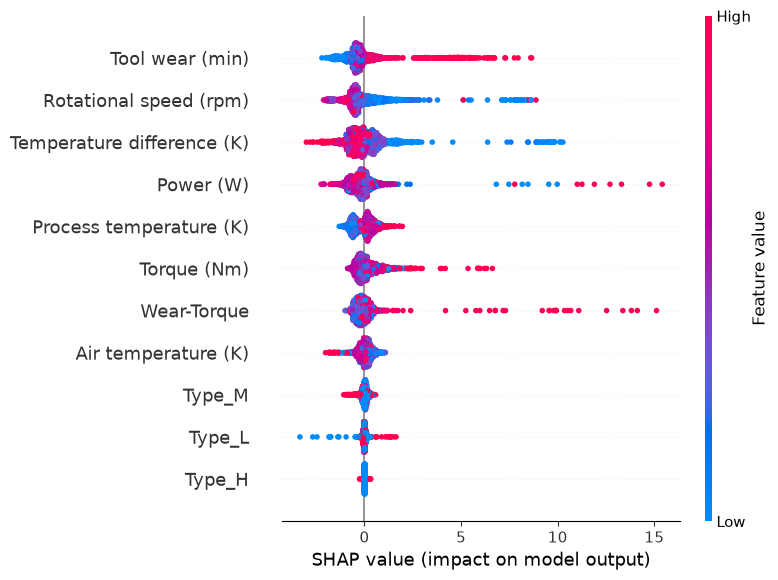

In [27]:
shap.summary_plot(
    shap_values.values,
    X_test_explain,
    feature_names=feature_names,
)

## 10. 主要特徴量の分析

In [28]:
important_features = [
    "Tool wear (min)",
    "Rotational speed (rpm)",
    "Temperature difference (K)",
    "Power (W)",
    "Wear-Torque",
]

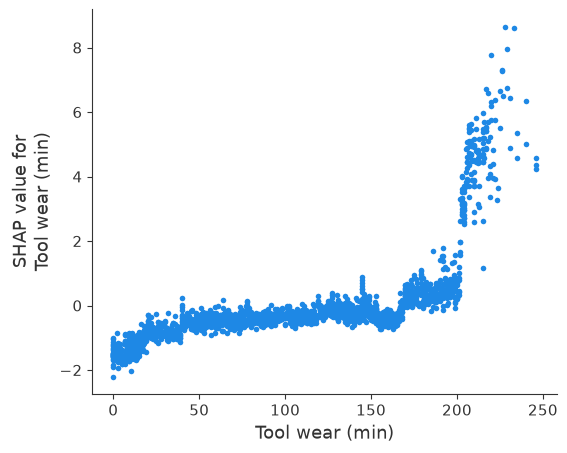

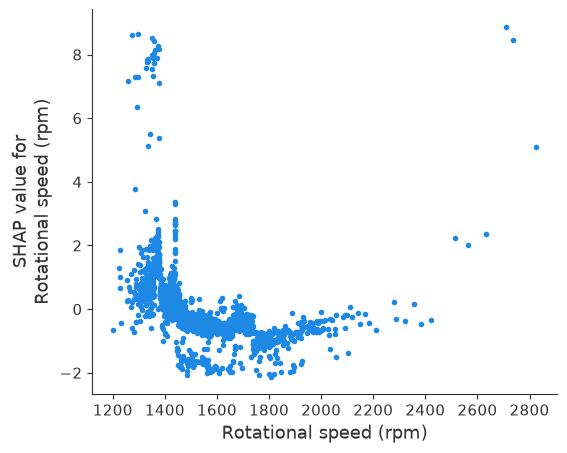

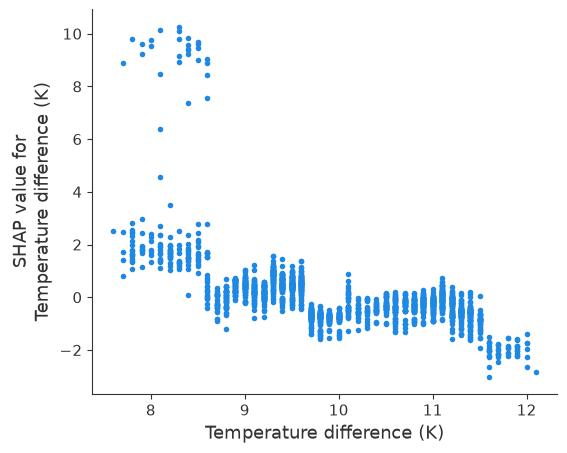

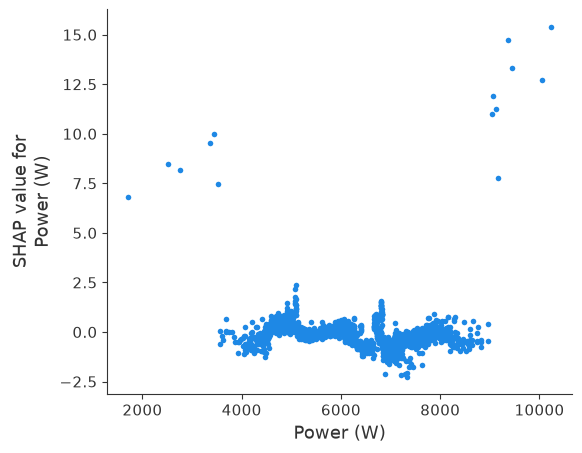

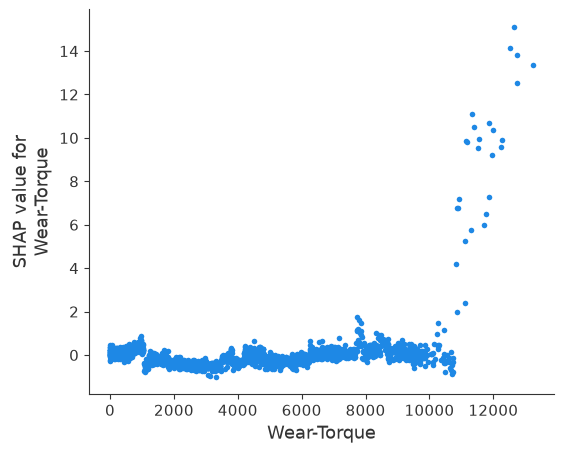

In [29]:
for feature in important_features:
    shap.dependence_plot(
        feature,
        shap_values.values,
        X_test_explain,
        feature_names=feature_names,
        interaction_index=None,
    )

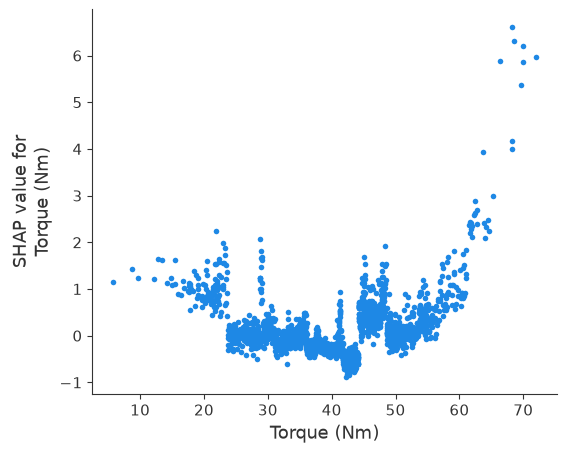

In [30]:
shap.dependence_plot(
    "Torque (Nm)",
    shap_values.values,
    X_test_explain,
    feature_names=feature_names,
    interaction_index=None,
)

### Summary Plotの解釈

SHAP Summary Plotでは、
Tool wear、Rotational speed、Temperature differenceの
影響が特に大きかった。

Tool wearでは、高い値を持つ設備が
SHAP値の正方向に分布する傾向が見られた。
このことから、工具摩耗が大きい設備では、
モデルが故障リスクを高く評価する傾向がある。

Rotational speedでは、
低い値が大きな正のSHAP値を持つケースが確認された。
一方で、回転速度と故障リスクの関係は単純な単調関係ではなく、
他の特徴量との組み合わせも影響している可能性がある。

Temperature differenceでは、
低い値がSHAP値の正方向に分布する傾向が見られ、
Process temperatureとAir temperatureの差が小さいケースが
故障予測を押し上げる場合があることが確認された。

Powerでは、一部の高い値が
非常に大きな正のSHAP値を持っていた。

また、TorqueおよびWear-Torqueでも、
高い値を持つ一部の設備で
故障方向への大きな影響が確認された。

これらの結果から、
LightGBMは単一のセンサー値だけではなく、
摩耗、回転状態、温度差、設備負荷などを組み合わせて
故障リスクを判断していると考えられる。

ただし、SHAPはモデルの予測根拠を説明するものであり、
各特徴量と設備故障との因果関係を示すものではない。

### Dependence Plotによる分析

SHAP Dependence Plotを用いて、
主要特徴量の値と故障予測への影響の関係を確認した。

#### Tool wear

Tool wearでは、値が小さい領域ではSHAP値が
主に負の値となっていた。

一方、約200分を超える領域からSHAP値が急激に上昇し、
故障方向への影響が大きくなる傾向が確認された。

このことからモデルは、
工具摩耗が特に大きい設備を
高リスクと評価する傾向がある。

#### Rotational speed

Rotational speedでは単純な単調関係は見られなかった。

特に約1,400 rpmを下回る低回転域では、
正のSHAP値が大きくなるケースが多く、
モデルが故障方向へ判断する傾向が確認された。

また、データ数は少ないものの、
極端に高い回転速度でも大きな正のSHAP値を持つケースが存在した。

このことから、モデルは通常の回転速度から大きく外れた
一部の運転状態を故障リスクとして捉えている可能性がある。

#### Temperature difference

Temperature differenceでは、
値が大きくなるにつれてSHAP値が低下する傾向が見られた。

特に約8.5 K以下の領域では正のSHAP値が多く、
8 K前後では故障方向への非常に大きな影響を持つケースも確認された。

一方、約10 K以上では負のSHAP値が多くなった。

このことから、Process temperatureとAir temperatureの差が
比較的小さい状態をモデルが故障リスクとして
利用していることが分かる。

#### Power

Powerでは、多くの設備が約4,000〜9,000 Wの範囲に分布し、
この領域ではSHAP値の影響は比較的小さかった。

一方、約9,000 Wを超える高出力領域では、
非常に大きな正のSHAP値を持つ設備が確認された。

そのため、極端に高いPowerは
モデルの故障予測を強く押し上げる要因の一つとなっている。

#### Wear-Torque

Wear-Torqueでは、
多くの領域でSHAP値は0付近だった。

一方、約11,000を超える領域から
SHAP値が急激に上昇する傾向が確認された。

工具摩耗とTorqueの両方が大きい状態を表すこの派生特徴量が、
特定の高負荷・高摩耗状態をモデルが識別するために
利用されていると考えられる。

#### Torque

Torqueでは、約25〜55 Nmの範囲では
SHAP値は比較的小さかった。

一方、約60 Nmを超えるとSHAP値が上昇し始め、
65 Nm以上では故障方向への大きな影響が確認された。

この結果から、特に高いTorqueを持つ設備では、
モデルが故障リスクを高く評価する傾向がある。

### 分析結果

Dependence Plotから、
LightGBMは各特徴量に対して単純な線形関係ではなく、
特定の値の領域で故障リスクを大きく変化させていることが確認できた。

特に、

- Tool wearが約200分を超える領域
- Rotational speedが約1,400 rpmを下回る領域
- Temperature differenceが約8.5 K以下の領域
- Powerが約9,000 Wを超える領域
- Wear-Torqueが約11,000を超える領域
- Torqueが約60 Nmを超える領域

では、故障方向への影響が大きくなる傾向が見られた。

ただし、これらはSHAP Dependence Plotから観察された
モデル内部の予測傾向であり、
実際の設備故障に対する物理的な安全基準値や
因果関係を示すものではない。

## 11. 個別設備の予測理由

In [31]:
prediction_results = pd.DataFrame(
    {
        "actual": y_test,
        "predicted": test_pred,
        "failure_probability": test_proba,
    },
    index=X_test.index,
)

true_positives = prediction_results[
    (prediction_results["actual"] == 1)
    & (prediction_results["predicted"] == 1)
].sort_values(
    "failure_probability",
    ascending=False,
)

true_positives.head(10)

,actual,predicted,failure_probability
9664,1,1,0.999974
8245,1,1,0.999963
6497,1,1,0.999959
8307,1,1,0.999952
4342,1,1,0.999943
4495,1,1,0.999860
4170,1,1,0.999857
4565,1,1,0.999850
4661,1,1,0.999820
4601,1,1,0.999819


In [32]:
high_risk_index = true_positives.index[0]

high_risk_position = (
    X_test_explain.index.get_loc(
        high_risk_index
    )
)

print(
    "Index:",
    high_risk_index,
)

print(
    "Actual:",
    y_test.loc[high_risk_index],
)

print(
    "Predicted:",
    test_pred[high_risk_position],
)

print(
    "Failure probability:",
    test_proba[high_risk_position],
)

X_test_explain.loc[
    high_risk_index
]

Index: 9664
Actual: 1
Predicted: 1
Failure probability: 0.9999741565350853


Air temperature (K)             299.100000
Process temperature (K)         310.200000
Rotational speed (rpm)         1317.000000
Torque (Nm)                      54.800000
Tool wear (min)                 231.000000
Power (W)                      7557.792279
Wear-Torque                   12658.800000
Temperature difference (K)       11.100000
Type_H                            0.000000
Type_L                            1.000000
Type_M                            0.000000
Name: 9664, dtype: float64

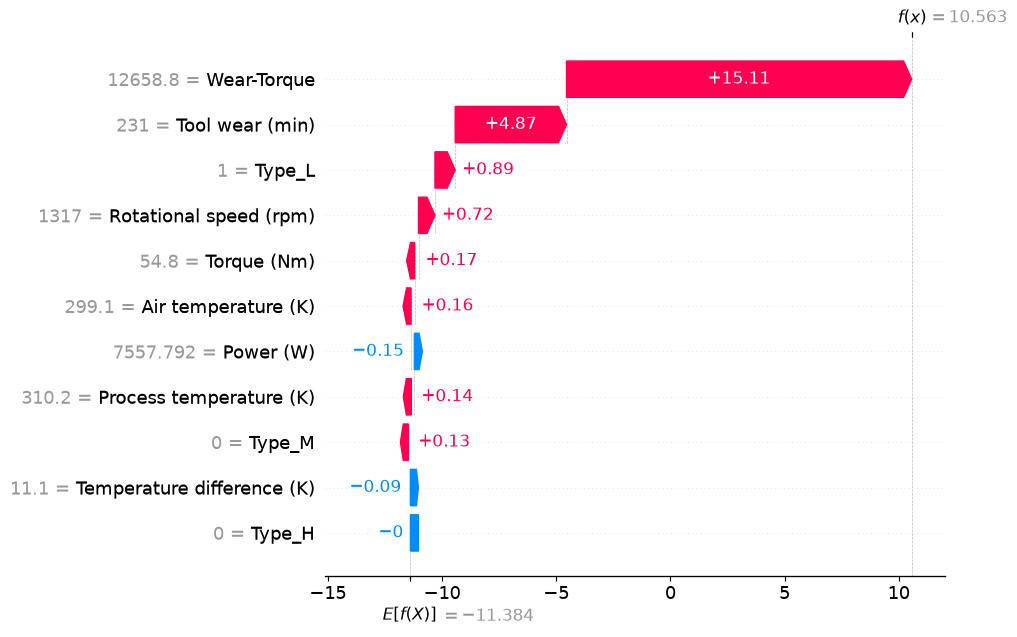

In [33]:
shap.plots.waterfall(
    shap_values[
        high_risk_position
    ],
    max_display=11,
)

### 高リスク設備の予測理由

TestデータのTrue Positiveの中から、
故障確率が最も高かったIndex 9664を分析した。

この設備は実際に故障しており、
LightGBMも故障と予測した。
予測された故障確率は約99.997%だった。

主な特徴量は以下だった。

- Tool wear: 231 min
- Rotational speed: 1317 rpm
- Torque: 54.8 Nm
- Power: 7557.8 W
- Wear-Torque: 12658.8
- Temperature difference: 11.1 K
- Type: L

Waterfall Plotでは、
Wear-Torqueが故障方向への最も大きな影響を持ち、
SHAP値は+15.11だった。

Tool wearも+4.87と大きく故障方向へ影響した。

さらに、Rotational speedも+0.72となり、
故障方向への判断に寄与した。

一方、PowerとTemperature differenceは
わずかに正常方向へ影響していた。

この結果から、モデルは単一の特徴量だけで
高リスクと判断したのではなく、
特に高いWear-TorqueとTool wear、
低いRotational speedなど複数の設備状態を組み合わせて、
故障リスクを非常に高く評価したことが分かる。

このような個別予測の説明を表示することで、
保全担当者は単に故障確率を見るだけではなく、
どの設備状態がモデルの高リスク判定につながったのかを
確認できる。

なお、Waterfall PlotのSHAP値は
予測確率に対する直接的な増減率ではなく、
LightGBMのモデル出力に対する各特徴量の寄与を表している。
また、SHAPによる説明は因果関係を示すものではない。

In [34]:
false_negatives = prediction_results[
    (prediction_results["actual"] == 1)
    & (prediction_results["predicted"] == 0)
].sort_values(
    "failure_probability",
    ascending=False,
)

false_negatives

,actual,predicted,failure_probability
7884,1,0,0.378060
3695,1,0,0.008950
2864,1,0,0.008037
4034,1,0,0.002096
7087,1,0,0.001117
7849,1,0,0.000455
9015,1,0,0.000180
2941,1,0,0.000117
2671,1,0,0.000093
1996,1,0,0.000021


In [35]:
fn_index = false_negatives.index[0]

fn_position = X_test_explain.index.get_loc(
    fn_index
)

print(
    "Index:",
    fn_index,
)

print(
    "Actual:",
    y_test.loc[fn_index],
)

print(
    "Predicted:",
    test_pred[fn_position],
)

print(
    "Failure probability:",
    test_proba[fn_position],
)

print(
    "Threshold:",
    selected_threshold,
)

X_test_explain.loc[
    fn_index
]

Index: 7884
Actual: 1
Predicted: 0
Failure probability: 0.37806001099630676
Threshold: 0.4802020202020202


Air temperature (K)            300.800000
Process temperature (K)        312.400000
Rotational speed (rpm)        1465.000000
Torque (Nm)                     59.100000
Tool wear (min)                 91.000000
Power (W)                     9066.793478
Wear-Torque                   5378.100000
Temperature difference (K)      11.600000
Type_H                           0.000000
Type_L                           1.000000
Type_M                           0.000000
Name: 7884, dtype: float64

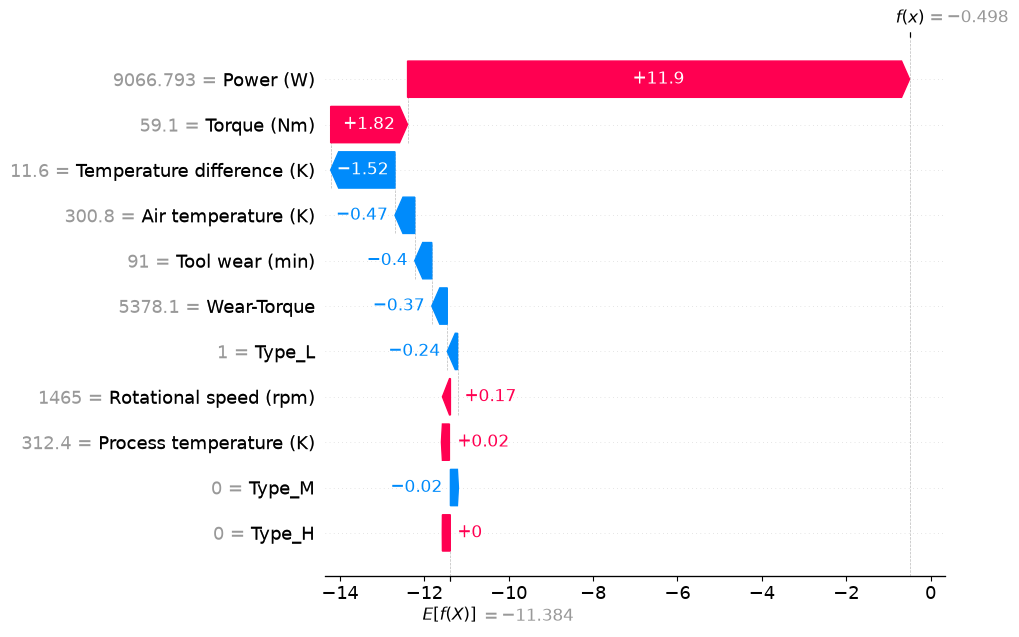

In [36]:
shap.plots.waterfall(
    shap_values[fn_position],
    max_display=11,
)

### False Negativeの分析

モデルの弱点を確認するため、
実際には故障していたものの正常と予測された
False Negativeについても分析した。

Testデータでは68件の故障のうち12件を見逃していた。

その中で判定閾値に最も近かったIndex 7884を分析した。

この設備の故障確率は約0.378で、
判定閾値約0.480を下回ったため正常と判定された。

主な特徴量は以下だった。

- Power: 9066.8 W
- Torque: 59.1 Nm
- Rotational speed: 1465 rpm
- Tool wear: 91 min
- Wear-Torque: 5378.1
- Temperature difference: 11.6 K

Waterfall Plotでは、
Powerが+11.90、Torqueが+1.82となり、
モデル出力を大きく故障方向へ押し上げていた。

一方、Temperature differenceは-1.52、
Air temperatureは-0.47、
Tool wearは-0.40、
Wear-Torqueは-0.37となり、
正常方向へ影響していた。

特にPowerとTorqueからは強い故障方向の兆候を
モデルが捉えていたものの、
その他の特徴量やモデル全体の基準値との組み合わせによって、
最終的な故障確率は判定閾値を超えなかった。

この事例から、単一の異常な特徴量だけでは
必ずしも故障判定にならず、
複数の設備状態の組み合わせによって
最終判断が変化することが確認できた。

また、実運用では故障確率が閾値未満であっても、
閾値に比較的近い設備や、
特定の特徴量で強い異常方向の寄与が確認された設備を
「要注意」として保全担当者に提示する方法も考えられる。

ただし、この運用ルールを採用する場合は、
実際の故障コストや点検コストを用いて
別途検証する必要がある。

## 12. 保全業務での活用

本モデルでは、設備ごとの故障確率だけではなく、
SHAPを用いて予測に影響した特徴量を確認できる。

そのため、保全担当者に対して
単に「故障リスクが高い」と通知するだけではなく、
その判断につながった設備状態も合わせて提示できる。

例えば高リスク設備について、

- 故障リスク
- リスク判定
- 主なリスク要因
- 現在のセンサー値
- 各特徴量の予測への影響

を表示することが考えられる。

これにより保全担当者は、
モデルの予測値だけを確認するのではなく、
どの設備状態を確認すべきかを判断するための
補助情報としてモデルを利用できる。

また、設備を故障確率の高い順にランキングすることで、
限られた保全リソースの中で
点検対象の優先順位付けを支援できる。

一方、本モデルにはFalse Negativeも存在する。

そのため、モデルによる故障予測を
設備点検の代替として使用するのではなく、
保全担当者の意思決定を支援する情報の一つとして
利用することが適切だと考える。

## 13. 注意点・限界

### SHAPは因果関係を示さない

SHAPはモデルが予測を行う際に、
各特徴量がモデル出力へどの程度影響したかを説明する手法である。

そのため、SHAP値が大きい特徴量が
実際の設備故障の原因であることを示すものではない。

### 特徴量間に相関が存在する

PowerはRotational speedとTorqueから、
Wear-TorqueはTool wearとTorqueから作成している。

そのため、元特徴量と派生特徴量の間には相関が存在し、
SHAPの寄与が複数の特徴量に分散する可能性がある。

個々のSHAP値を独立した影響として
過度に解釈しないよう注意が必要である。

### 使用データは合成データである

AI4I 2020 Predictive Maintenance Datasetは
実際の製造設備を模した合成データである。

そのため、本分析で確認された特徴量の境界値や傾向を
実際の製造設備へそのまま適用することはできない。

実運用では実設備のセンサーデータを用いて
モデルを再学習・検証する必要がある。

### 誤判定が存在する

Testデータでは68件の故障のうち12件を見逃した。

したがって、本モデルだけを根拠として
設備の安全性や点検の要否を自動決定することは適切ではない。

モデルは保全担当者の判断を支援するための
補助情報として利用することを想定する。

## 14. 次のステップ

SHAPを用いることで、
モデル全体の特徴量の影響だけではなく、
個別設備について故障リスクが高くなった理由や
モデルが故障を見逃した事例も分析できた。

これまでの分析によって、
故障予測モデルの構築・評価・説明まで完了した。

次のフェーズでは、
分析結果を実際に利用できるシステムへ発展させる。

具体的には以下を実施する。

1. 分析・推論処理を再利用可能なPythonコードとして整理する。
2. 学習済みモデルを保存・読み込みできるようにする。
3. PostgreSQLのデータモデルを設計する。
4. FastAPIによる故障予測APIを構築する。
5. SvelteKitで設備一覧・故障リスク・予測理由を表示する。
6. 故障確率による設備ランキングを実装する。
7. テストとデプロイ環境を整備する。

最終的には、
設備データの確認から故障リスクの予測、
保全対象設備の優先順位付けまでを
一つのWebシステム上で行える状態を目指す。